# Import Libraries

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [85]:
df = pd.read_csv("Churn_Modelling (1).csv")

In [86]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [87]:
df.shape

(10000, 14)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [89]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [90]:
df = df.drop(["RowNumber","CustomerId","Surname"], axis=1)

In [91]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [92]:
df.duplicated().sum()

np.int64(0)

# EDA

In [93]:
# Customer Churn Distribution

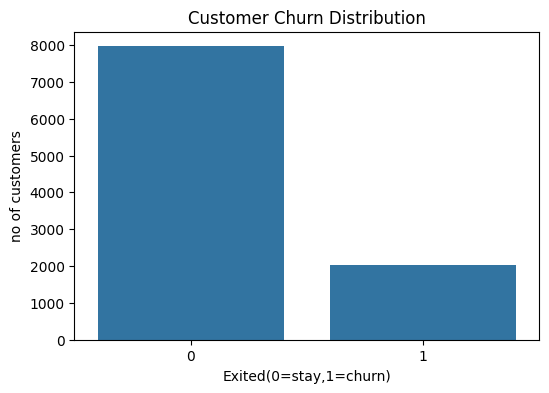

In [94]:
plt.figure(figsize=(6,4))
sns.countplot(x= "Exited",data = df)
plt.title("Customer Churn Distribution")
plt.xlabel("Exited(0=stay,1=churn)")
plt.ylabel("no of customers")
plt.show()

Text(0, 0.5, 'no of customers')

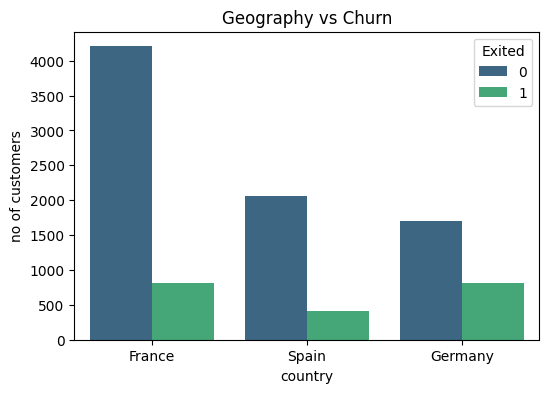

In [95]:
plt.figure(figsize=(6,4))
sns.countplot(x = "Geography",hue="Exited", palette="viridis",data=df)
plt.title ("Geography vs Churn")
plt.xlabel("country")
plt.ylabel("no of customers")

C:\Users\Mujahid\AppData\Local\Temp\ipykernel_16132\1734253552.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=df, palette='coolwarm')


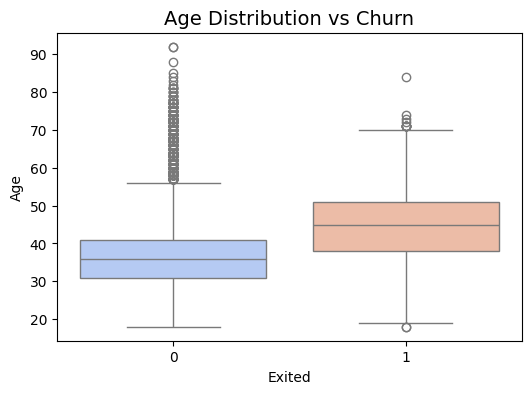

In [96]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Exited', y='Age', data=df, palette='coolwarm')

plt.title("Age Distribution vs Churn", fontsize=14)
plt.xlabel("Exited")
plt.ylabel("Age")

plt.show()

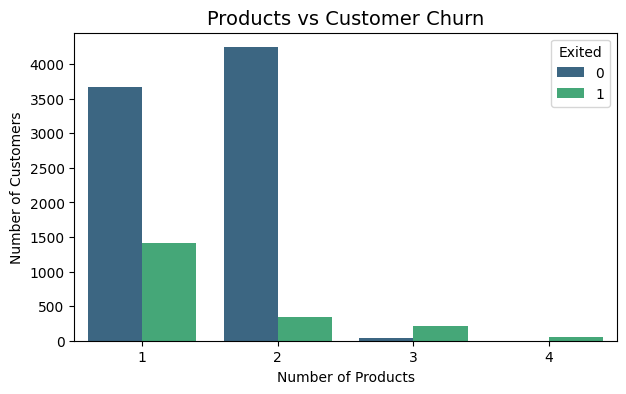

In [97]:
plt.figure(figsize=(7,4))
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='viridis')

plt.title("Products vs Customer Churn", fontsize=14)
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

plt.show()

# Encode Categorical Columns

In [98]:
df.select_dtypes(include ='object').columns

Index(['Geography', 'Gender'], dtype='object')

In [99]:
df['Gender'] = df['Gender'].map({'Male':1,'Female':0})

In [100]:
df = pd.get_dummies(df,columns=['Geography'],drop_first=True)

In [101]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [102]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [64]:
# Features aur Target Split

In [103]:
X = df.drop('Exited',axis=1)
y = df['Exited']

In [104]:
# train test slpit

In [105]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

In [106]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 11)
X_test: (2000, 11)
y_train: (8000,)
y_test: (2000,)


In [69]:
# Feature Scaling

In [107]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [119]:
import joblib

joblib.dump(xgb_model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [108]:
# Logistic Regression

In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("logistic regression accuracy score",accuracy_score(y_test,pred_lr))


logistic regression accuracy score 0.811


In [73]:
# random forest classifier

In [110]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)


print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Random Forest Accuracy: 0.8665


In [111]:
# xg boost

In [112]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, pred_xgb))

d:\churn_project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:23:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8695


In [77]:
# model comparrission table

In [113]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_xgb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.8110
1,Random Forest,0.8665
2,XGBoost,0.8695


In [114]:
# best model

In [115]:
import joblib

joblib.dump(xgb_model, "churn_model.pkl")

['churn_model.pkl']

In [116]:
# Feature Importance Graph

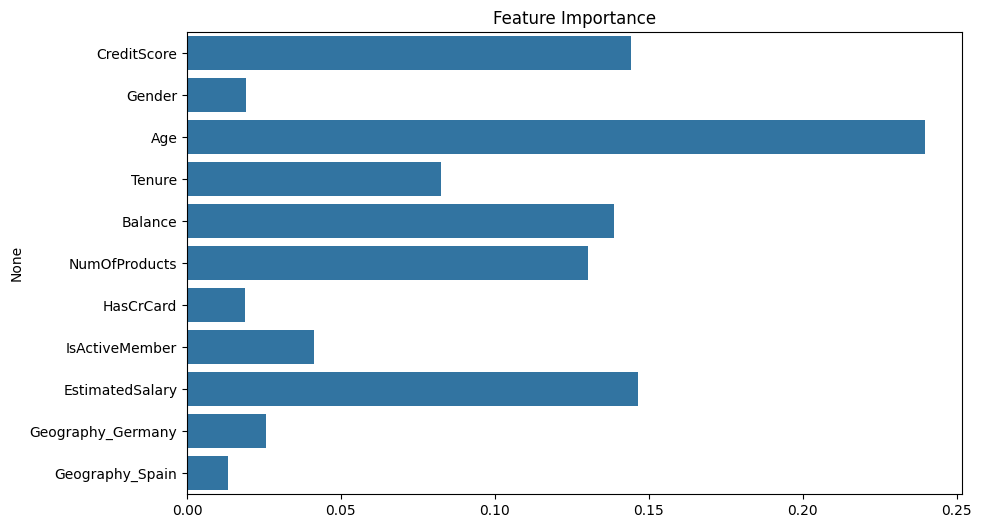

In [117]:
importances = rf.feature_importances_
features = df.drop("Exited", axis=1).columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

In [83]:
!pip install streamlit


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
